In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score,silhouette_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Conv2D, MaxPooling2D, Flatten, ReLU
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist


I0000 00:00:1788473038.231202   37583 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788473038.236706   37583 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788473039.715473   37583 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788473043.102713   37583 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
file = "results.txt"

In [3]:
def standard_scaler_1():
    global X_train_scaled, X_test_scaled
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

In [4]:
def linear_regression():
    global y_pred
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    MODELS.append("Linear Regression")
    MSE.append(mse)
    R2.append(r2)

In [5]:
def ridge():
    ridge = Ridge(alpha = 1.0)
    ridge.fit(X_train_scaled, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled)
    mse = mean_squared_error(y_test,y_pred_ridge)
    r2 = r2_score(y_test, y_pred_ridge)
    MODELS.append("Ridge")
    MSE.append(mse)
    R2.append(r2)

In [6]:
def pcr():
    pca_model = PCA(n_components = 3)
    X_train_pca = pca_model.fit_transform(X_train_scaled)
    X_test_pca = pca_model.transform(X_test_scaled)
    pca_linear = LinearRegression()
    pca_linear.fit(X_train_pca , y_train)
    y_pred_pcr = pca_linear.predict(X_test_pca)
    mse = mean_squared_error(y_test, y_pred_pcr)
    r2 = r2_score(y_test, y_pred_pcr)
    MODELS.append("PCR (3 component)")
    MSE.append(mse)
    R2.append(r2)

In [7]:
def pls():
    pls_model = PLSRegression(n_components = 3)
    pls_model.fit(X_train_scaled, y_train)
    y_pred_pls = pls_model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred_pls)
    r2 = r2_score(y_test, y_pred_pls)
    MODELS.append("PLS (3 component)")
    MSE.append(mse)
    R2.append(r2)

In [8]:
def standard_scaler_2():
    global X_train_scaler, X_test_scaler, y_train_scaler, y_scaler
    X_scaler = StandardScaler()
    y_scaler = StandardScaler()
    X_train_scaler = X_scaler.fit_transform(X_train)
    X_test_scaler = X_scaler.transform(X_test)
    y_train_scaler = y_scaler.fit_transform(y_train.values.reshape(-1,1)).ravel()

In [9]:
def artificial_neural_network():
    global y_pred_ysa
    ysa_model = MLPRegressor(hidden_layer_sizes =(100,50), max_iter=2000, random_state=42)
    ysa_model.fit(X_train_scaler, y_train_scaler)
    y_pred_scaled = ysa_model.predict(X_test_scaler).reshape(-1,1)
    y_pred_ysa = y_scaler.inverse_transform(y_pred_scaled).ravel()
    mse = mean_squared_error(y_test,y_pred_ysa)
    r2 = r2_score(y_test, y_pred_ysa)
    MODELS.append("Artificial Neural Network")
    MSE.append(mse)
    R2.append(r2)

In [10]:
MODELS = []
MSE = []
R2 = []

def regression_analysis():
    global X_train, X_test, y_train, y_test
    data_bus = "proje_ev_fiyatlari.csv"
    data = pd.read_csv(data_bus)
    X = data.drop(["fiyat"], axis =1)
    y = data["fiyat"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    standard_scaler_1()
    linear_regression()
    ridge()
    pcr()
    pls()
    standard_scaler_2()
    artificial_neural_network()
    table = {
        "Model" : MODELS,
        "MSE" : MSE,
        "R2" : R2
    }
    df = pd.DataFrame(table)
    with open(file,"a",encoding="utf-8") as f:
        f.write("\n"+ "="*40+"\n")
        f.write("MODEL-1:Regression Analysis Results")
        f.write("\n"+"="*40+"\n")
        f.write("\n")
        f.write("Methods Used -->"+"\n"+"Linear Regression"+"\n"+"Ridge"+"\n"+"PCR"+"\n"+"PLS"+"Artificial Neural Network(MLP)"+"\n")
        f.write("\n")
        f.write("Success Criteria -->"+"\n"+"MSE"+"\n"+"Rˆ2"+"\n")
        f.write("\n")
        f.write("Success Values -->"+"\n")
        f.write("\n")
        f.write(df.to_string(index=False)+"\n\n")
        f.write("\n")

In [11]:
def cluster_standard():
    global X, X_scaled, scaler, data
    data_bus  = "proje_musteri_segmentasyonu.csv"
    data = pd.read_csv(data_bus)
    X = data[["yillik_gelir","harcama_puani"]]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

def elbow():
    global k_values, inertia_list
    k_values = range(1,11)
    inertia_list = []
    for k in k_values:
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
        kmeans.fit(X_scaled)
        inertia_list.append(kmeans.inertia_)

def cluster_analysis():
    cluster_standard()
    elbow()

    plt.figure(figsize=(8,6))
    plt.plot(k_values,inertia_list, marker="o")
    plt.title("Elbow Plot")
    plt.xlabel("Cluster Values")
    plt.ylabel("Inertia")
    plt.show()
    plt.close()

    k = 5
    kmean= KMeans(n_clusters=k, n_init=10, random_state=42)
    kmean.fit(X_scaled)
    y_pred = kmean.predict(X_scaled)

    centers = kmean.cluster_centers_
    labels = kmean.labels_
    original_centers = scaler.inverse_transform(centers)
    X_original = scaler.inverse_transform(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_original[:,0], X_original[:,1], c =labels, s=35,label="data")
    plt.scatter(original_centers[:,0], original_centers[:,1],c ="red", s= 200, marker="x", label="cluster centers")
    plt.xlabel("Annual Income")
    plt.ylabel("Spending Points")
    plt.legend()
    plt.show()
    plt.close()

    score = silhouette_score(X_scaled, y_pred)
    print(f"Silhouette Score: {score:.2f}")

    data["cluster"] = y_pred

    print(data.groupby("cluster")[["yillik_gelir","harcama_puani"]].mean())
    print("")
    averages_table = data.groupby("cluster")[["yillik_gelir","harcama_puani"]].mean().to_string()

    with open(file,"a",encoding="utf-8") as f:
       f.write("\n"+ "="*40+"\n")
       f.write("MODEL-2:Cluster Analysis Results")
       f.write("\n"+"="*40+"\n")
       f.write("\n")
       f.write("Method Used-->"+"\n"+"KMeans Clustering (k=5)"+"\n")
       f.write("\n")
       f.write("Success Criterion-->"+"\n"+"Silhouette Score"+"\n")
       f.write("\n")
       f.write("Success Value -->"+"\n")
       f.write(f"Silhouette Score: {score:.2f}"+"\n")
       f.write("\n")
       f.write(f"Optimal Number of Clusters: {k}"+"\n")
       f.write("\n")
       f.write("Cluster Averages Table"+"\n")
       f.write("\n")
       f.write(averages_table+"\n")
       f.write("\n")
       f.write("Segment Definitions"+"\n")
       f.write("\n")
       f.write("Cluster 0 = High Annual Income & Low Spending Score (Customer Attainable via Campaign)"+"\n")
       f.write("Cluster 1 = Low Annual Income & High Spending Score"+"\n")
       f.write("Cluster 2 = High Annual Income & High Spending Score (Most Valuable Segment)"+"\n")
       f.write("Cluster 3 = Low Annual Income & Low Spending Score"+"\n")
       f.write("Cluster 4 = Medium Annual Income & Medium Spending Score"+"\n")

#We can categorize the resulting segments as follows:
#Cluster 0 = High Annual Income & Low Spending Score (Customer who can be won over via campaigns)
#Cluster 1 = Low Annual Income & High Spending Score
#Cluster 2 = High Annual Income & High Spending Score (Most Valuable Segment)
#Cluster 3 = Low Annual Income & Low Spending Score
#Cluster 4 = Medium Annual Income & Medium Spending Score



In [12]:
def text_sentiment_analysis():
    data_bus = "IMDB Dataset.csv"
    model_bus = "rnn.h5"

    data = pd.read_csv(data_bus)
    data["sentiment"] = data["sentiment"].astype(object)
    data.loc[data["sentiment"]=="positive","sentiment"]=1
    data.loc[data["sentiment"]=="negative","sentiment"]=0

    X = data["review"]
    y = data["sentiment"]

    tokenizer = Tokenizer(num_words=10000)
    tokenizer.fit_on_texts(X)
    index = tokenizer.texts_to_sequences(X)
    len_word = 300
    still = pad_sequences(index, maxlen=len_word)

    X_train, X_test, y_train, y_test = train_test_split(still,y,test_size=0.2, random_state=42)

    X_train = np.asarray(X_train).astype("float32")
    X_test = np.asarray(X_test).astype("float32")
    y_train = np.asarray(y_train).astype("float32")
    y_test = np.asarray(y_test).astype("float32")

    model = Sequential([
       Embedding(input_dim=10000, output_dim=32),
       SimpleRNN(32),
       Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
    model.save(model_bus)

    loss, acc = model.evaluate(X_test, y_test)
    print(f"Test Accuracy: %{acc*100:.2f}")
    print(f"Test Loss: {loss:.4f}")

    with open(file, "a",encoding="utf-8") as f:
        f.write("\n"+"="*40+"\n")
        f.write("MODEL-3:Text Sentiment Analysis Results")
        f.write("\n"+"="*40+"\n")
        f.write("\n")
        f.write("Methods Used -->"+"\n"+"SimpleRNN (Embedding + SimpleRNN + Dense)"+"\n")
        f.write("\n")
        f.write("Success Criterion -->"+"\n"+"Test Accuracy (accuracy) ve Test Loss(Binary Cross-Entropy)"+"\n")
        f.write("\n")
        f.write("Performance Metrics-->"+"\n")
        f.write(f"Test Accuracy: %{acc*100:.2f}"+"\n")
        f.write(f"Test Loss: {loss:.4f}"+"\n")
        f.write("\n")


In [13]:
def image_classification():
    (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

    X_train = X_train.reshape(-1,28,28,1)/255
    X_test = X_test.reshape(-1,28,28,1)/255

    cnn_model = Sequential([
        Conv2D(32,(3,3),input_shape=(28,28,1)),
        MaxPooling2D((2,2)),
        Conv2D(64,(3,3)),
        ReLU(),
        MaxPooling2D((2,2)),
        Conv2D(128,(3,3)),
        ReLU(),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128,activation="relu"),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(10, activation="softmax")
    ])

    cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cnn_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

    y_pred = cnn_model.predict(X_test).argmax(axis=1)

    classes = ["T-shirt/Top", "Pants", "Sweater", "Dress", "Coat", "Sandals", "Shirt", "Sneakers", "Bag", "Boots"]

    test_loss, test_acc = cnn_model.evaluate(X_test, y_test)
    print(f"Test Accuracy: %{test_acc*100:.2f}")
    print(f"Test Loss: {test_loss:.4f}")

    with open(file,"a",encoding="utf-8") as f:
        f.write("\n"+"="*40+"\n")
        f.write("MODEL-4: Image Classification Analysis")
        f.write("\n"+"="*40+"\n")
        f.write("\n")
        f.write("Method Used -->"+"\n"+"CNN - Convolutional Neural Network (Conv2D + MaxPooling2D)"+"\n")
        f.write("\n")
        f.write("Success Criteria -->"+"\n"+"Test Accuracy (Categorical Accuracy) ve Test Loss"+"\n")
        f.write("\n")
        f.write("Success Values-->"+"\n")
        f.write(f"Test Accuracy: {test_acc*100:.2f}"+"\n")
        f.write(f"Test Loss: {test_loss:.4f}"+"\n")
        f.write("\n")
        f.write("Mixed-Ability Classes-->"+"\n")
        f.write("\n")

        for i in range(10):
            incorrect_guess = []
            for real, guess in zip(y_test,y_pred):
                if real == i and guess != i:
                    incorrect_guess.append(guess)

            if len(incorrect_guess) == 0:
                continue
            easily_confused = max(set(incorrect_guess), key=incorrect_guess.count)
            piece = incorrect_guess.count(easily_confused)

            line = f"{classes[i]}, is most frequently confused with {classes[easily_confused]} ({piece} example)\n"

            f.write(line)
        f.write("\n")


1 - Regression Analysis
2 - Cluster Analysis
3 - Text Sentiment Analysis
4 - Image Classification
5 - Exit


/workspaces/229404462/.venv-1/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788473049.278097   37583 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 23s 22ms/step - accuracy: 0.7635 - loss: 0.6501 - val_accuracy: 0.8121 - val_loss: 0.5152
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8408 - loss: 0.4388 - val_accuracy: 0.8500 - val_loss: 0.4179
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.8597 - loss: 0.3824 - val_accuracy: 0.8507 - val_loss: 0.4076
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.8756 - loss: 0.3389 - val_accuracy: 0.8737 - val_loss: 0.3541
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8849 - loss: 0.3131 - val_accuracy: 0.8772 - val_loss: 0.3361
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - accuracy: 0.8924 - loss: 0.2900 - val_accuracy: 0.8772 - val_loss: 0.3382
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9002 - loss: 0.2674 - val_accuracy: 0.8851 - val_loss: 0.3234
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9048 - loss: 0.2528 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8229 - loss: 0.4738
Test Accuracy: %82.29
Test Loss: 0.4738
1 - Regression Analysis
2 - Cluster Analysis
3 - Text Sentiment Analysis
4 - Image Classification
5 - Exit
1 - Regression Analysis
2 - Cluster Analysis
3 - Text Sentiment Analysis
4 - Image Classification
5 - Exit


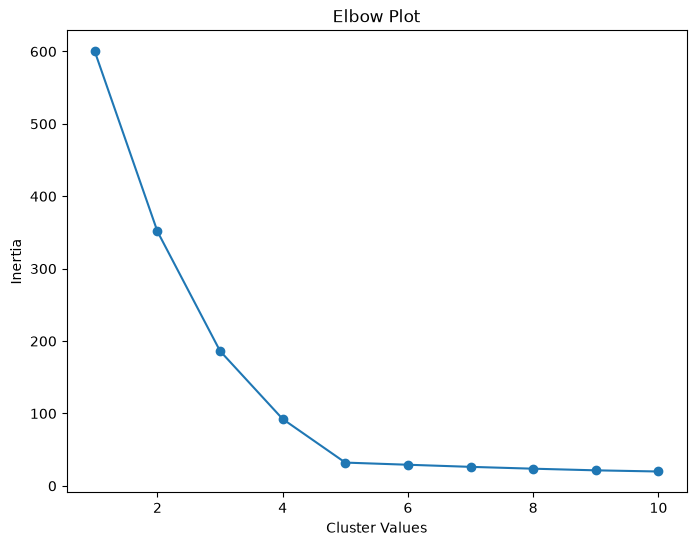

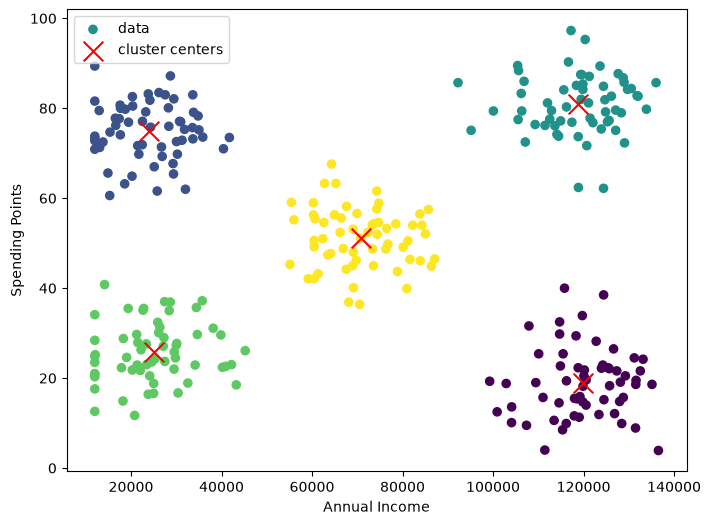

Silhouette Score: 0.72
          yillik_gelir  harcama_puani
cluster                              
0        119952.383333      18.975000
1         23898.250000      74.910000
2        118735.666667      80.858333
3         25038.666667      25.716667
4         70796.216667      51.130000

1 - Regression Analysis
2 - Cluster Analysis
3 - Text Sentiment Analysis
4 - Image Classification
5 - Exit
Logging out...


In [14]:
while True:
    print("1 - Regression Analysis")
    print("2 - Cluster Analysis")
    print("3 - Text Sentiment Analysis")
    print("4 - Image Classification")
    print("5 - Exit")
    try:
        vote = int(input("Enter the number of the operation you wish to perform from the list above."))
        if vote == 1:
            regression_analysis()
        elif vote == 2:
            cluster_analysis()
        elif vote == 3:
            text_sentiment_analysis()
        elif vote == 4:
            image_classification()
        elif vote == 5:
            print("Logging out...")
            break
        else:
            print("Invalid Selection.")
    except ValueError as mistake:
        print(mistake)
        print("Please enter only numbers!")

In [17]:
with open(file, "r", encoding="utf-8") as f:
    print(f.read())


MODEL-4: Image Classification Analysis

Method Used -->
CNN - Convolutional Neural Network (Conv2D + MaxPooling2D)

Success Criteria -->
Test Accuracy (Categorical Accuracy) ve Test Loss

Success Values-->
Test Accuracy: 88.29
Test Loss: 0.3379

Mixed-Ability Classes-->

T-shirt/Top, is most frequently confused with Shirt (148 example)
Pants, is most frequently confused with Dress (15 example)
Sweater, is most frequently confused with Shirt (102 example)
Dress, is most frequently confused with Coat (53 example)
Coat, is most frequently confused with Shirt (40 example)
Sandals, is most frequently confused with Boots (11 example)
Shirt, is most frequently confused with Coat (167 example)
Sneakers, is most frequently confused with Sandals (27 example)
Bag, is most frequently confused with Coat (7 example)
Boots, is most frequently confused with Sneakers (41 example)


MODEL-3:Text Sentiment Analysis Results

Methods Used -->
SimpleRNN (Embedding + SimpleRNN + Dense)

Success Criterion --

In [16]:
#with open(file,"w", encoding="utf-8") as f:
 #   pass
  #  print("Dosya temizlendi")